# Statistical Learning Theory: runnable companion

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hhsieh14/AI-courses-notes-reader/blob/main/courses/statistical-learning-theory/notebooks/slt_companion.ipynb)

Theory is easier to trust when you can watch it happen. Each section below checks a result from the notes numerically: a bound against a simulation, a duality against the primal, a convergence rate against its prediction. Needs only NumPy, SciPy, scikit-learn and Matplotlib, and runs in about a minute.

| § | Chapter | What the code checks |
|---:|---|---|
| 1 | [Probabilistic prediction](../docs/chapters/01_probabilistic_prediction.md) | a learned classifier's risk approaches the Bayes risk as $n$ grows |
| 2 | [Hard-margin SVM](../docs/chapters/02_hard_margin_svm.md) · [Soft margin](../docs/chapters/04_soft_margin_svm.md) | support vectors sit exactly on the margin; C trades margin for slack |
| 3 | [Kernels](../docs/chapters/03_feature_maps_and_kernels.md) · [RKHS & representer](../docs/chapters/05_rkhs_and_representer.md) | the kernel equals an explicit feature inner product; primal ridge = dual (representer) ridge |
| 4 | [Concentration](../docs/chapters/06_concentration_inequalities.md) | Hoeffding vs Chebyshev vs the true tail |
| 5 | [Rademacher complexity](../docs/chapters/07_generalization_and_rademacher.md) | Monte Carlo estimate vs the $B\sqrt{\sum\lVert x_i\rVert^2}/n$ bound |
| 6 | [VC dimension](../docs/chapters/08_vc_dimension.md) | half-planes shatter 3 points but never 4; Sauer–Shelah |
| 7 | [Smooth convex optimization](../docs/chapters/09_smooth_convex_optimization.md) | GD at rate $1-1/\kappa$ vs Nesterov at $1-1/\sqrt\kappa$ |
| 8 | [Proximal methods](../docs/chapters/10_nonsmooth_proximal_optimization.md) | ISTA/FISTA reach the scikit-learn lasso solution |
| 9 | [SGD](../docs/chapters/11_stochastic_gradient_descent.md) | constant steps stall at a noise floor; decaying steps converge |
| 10 | [Neural-network optimization](../docs/chapters/12_neural_network_optimization.md) | wide networks train "lazily": weights move $\propto1/\sqrt m$ |

In [1]:
import importlib, subprocess, sys
for pkg, mod in [("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib"),
                 ("scikit-learn", "sklearn"), ("statsmodels", "statsmodels"), ("PyWavelets", "pywt")]:
    if importlib.util.find_spec(mod) is None:          # e.g. on Colab, PyWavelets may be missing
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (6.5, 3.6), "axes.grid": True, "grid.alpha": 0.3})

## 1. Bayes risk: the floor no classifier can beat

Two classes $X\mid Y=\pm1\sim\mathcal N(\pm\mu,I)$ with equal priors. The Bayes classifier is $\mathrm{sign}(\mu^\top x)$, with risk $\Phi(-\lVert\mu\rVert)$. Logistic regression trained on $n$ samples approaches that floor as $n$ grows.

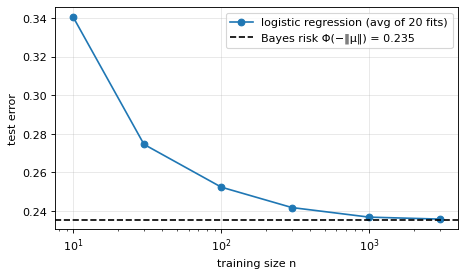

excess risk (test error − Bayes risk): n=10: 0.1050, n=30: 0.0392, n=100: 0.0170, n=300: 0.0064, n=1000: 0.0014, n=3000: 0.0004


In [2]:
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
d, mu = 5, np.array([0.6, 0.4, 0.0, 0.0, 0.0])
bayes = norm.cdf(-np.linalg.norm(mu))
def sample(n, rng):
    y = rng.choice([-1, 1], n); return y[:, None] * mu + rng.normal(size=(n, d)), y
rng = np.random.default_rng(0)
Xte, yte = sample(200_000, rng)
ns = [10, 30, 100, 300, 1000, 3000]
risk = [np.mean([1 - LogisticRegression().fit(*sample(n, rng)).score(Xte, yte) for _ in range(20)]) for n in ns]
plt.semilogx(ns, risk, "o-", label="logistic regression (avg of 20 fits)"); plt.axhline(bayes, color="k", ls="--", label=f"Bayes risk Φ(−‖μ‖) = {bayes:.3f}")
plt.xlabel("training size n"); plt.ylabel("test error"); plt.legend(); plt.show()
print("excess risk (test error − Bayes risk):", ", ".join(f"n={n}: {r - bayes:.4f}" for n, r in zip(ns, risk)))

## 2. Hard and soft margins

For separable data, a very large C gives the hard-margin SVM. Every support vector has functional margin exactly $y_i(w^\top x_i+b)=1$, and the geometric margin is $1/\lVert w\rVert$ on each side. Shrinking C buys a wider margin with slack $\xi_i=\max(0,1-y_i f(x_i))$.

In [3]:
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
Xs, ys = make_blobs(80, centers=2, cluster_std=1.0, random_state=6); ys = 2 * ys - 1
hard = SVC(kernel="linear", C=1e6).fit(Xs, ys)
w, b = hard.coef_.ravel(), hard.intercept_[0]
fm = ys * (Xs @ w + b)
print(f"min functional margin over all points: {fm.min():.4f}")
print(f"functional margin of the support vectors: {np.round(fm[hard.support_], 4)}")
print(f"margin width 2/‖w‖ = {2 / np.linalg.norm(w):.3f}\n")
print(" C        width   #SV   total slack Σξ   objective ½‖w‖²+CΣξ")
for Cv in (100, 1, 0.1, 0.01):
    m = SVC(kernel="linear", C=Cv).fit(Xs, ys); w = m.coef_.ravel()
    xi = np.maximum(0, 1 - ys * (Xs @ w + m.intercept_[0]))
    print(f"{Cv:<7}  {2/np.linalg.norm(w):6.3f}  {len(m.support_):4d}   {xi.sum():12.3f}   {0.5*w@w + Cv*xi.sum():10.3f}")

min functional margin over all points: 1.0000
functional margin of the support vectors: [1. 1.]
margin width 2/‖w‖ = 2.798

 C        width   #SV   total slack Σξ   objective ½‖w‖²+CΣξ
100       2.798     2          0.000        0.255
1         2.798     2          0.000        0.255
0.1       3.309     6          0.384        0.221
0.01      5.012    22          4.271        0.122


## 3. Kernels and the representer theorem

**Kernel = inner product of features.** For $x,z\in\mathbb R^2$, $(1+x^\top z)^2=\phi(x)^\top\phi(z)$ with $\phi(x)=(1,\sqrt2x_1,\sqrt2x_2,x_1^2,x_2^2,\sqrt2x_1x_2)$.

**A valid kernel gives a PSD Gram matrix.** All eigenvalues are $\ge0$ (up to round-off).

**Representer theorem.** The ridge solution lies in the span of the data: $w=X^\top\alpha$ with $\alpha=(K+\lambda I)^{-1}y$, which equals the primal $(X^\top X+\lambda I)^{-1}X^\top y$.

In [4]:
rng = np.random.default_rng(0)
phi = lambda x: np.array([1, np.sqrt(2)*x[0], np.sqrt(2)*x[1], x[0]**2, x[1]**2, np.sqrt(2)*x[0]*x[1]])
x, z = rng.normal(size=2), rng.normal(size=2)
print(f"(1 + x·z)^2 = {(1 + x @ z)**2:.6f}     φ(x)·φ(z) = {phi(x) @ phi(z):.6f}")

Xk = rng.normal(size=(200, 3))
sq = ((Xk[:, None] - Xk[None]) ** 2).sum(-1)
print("smallest eigenvalue of an RBF Gram matrix:", np.linalg.eigvalsh(np.exp(-0.5 * sq)).min())
print("smallest eigenvalue of a 'kernel' exp(+‖x−z‖²) (not a kernel):", np.linalg.eigvalsh(np.exp(0.1 * sq)).min())

n, p, lam = 50, 8, 0.7
Xr = rng.normal(size=(n, p)); yr = Xr @ rng.normal(size=p) + 0.1 * rng.normal(size=n)
w_primal = np.linalg.solve(Xr.T @ Xr + lam * np.eye(p), Xr.T @ yr)
alpha = np.linalg.solve(Xr @ Xr.T + lam * np.eye(n), yr)
print("primal ridge == X^T α (representer):", np.allclose(w_primal, Xr.T @ alpha))

(1 + x·z)^2 = 1.137769     φ(x)·φ(z) = 1.137769
smallest eigenvalue of an RBF Gram matrix: 5.0544713332488905e-08
smallest eigenvalue of a 'kernel' exp(+‖x−z‖²) (not a kernel): -320.29347007080787
primal ridge == X^T α (representer): True


## 4. Concentration: how far can an average stray?

For $n$ fair coin flips, compare the true tail $P(\lvert\bar X-\tfrac12\rvert\ge t)$ with Chebyshev's $\frac{1}{4nt^2}$ and Hoeffding's $2e^{-2nt^2}$. Hoeffding decays exponentially in $n$, and that's what makes the generalization bounds work.

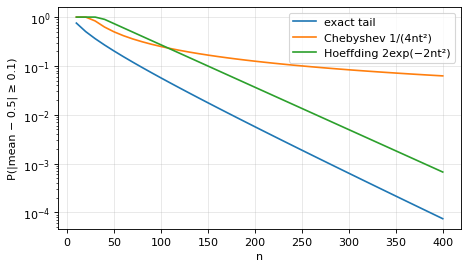

n=400: exact 7.43e-05, Chebyshev 6.25e-02, Hoeffding 6.71e-04


In [5]:
from scipy.stats import binom
t, ns = 0.1, np.arange(10, 401, 10)
true_tail = [binom.cdf(np.floor(n*(0.5 - t) + 1e-9), n, 0.5) + binom.sf(np.ceil(n*(0.5 + t) - 1e-9) - 1, n, 0.5) for n in ns]
plt.semilogy(ns, true_tail, label="exact tail")
plt.semilogy(ns, np.minimum(1, 1 / (4 * ns * t**2)), label="Chebyshev 1/(4nt²)")
plt.semilogy(ns, np.minimum(1, 2 * np.exp(-2 * ns * t**2)), label="Hoeffding 2exp(−2nt²)")
plt.xlabel("n"); plt.ylabel(f"P(|mean − 0.5| ≥ {t})"); plt.legend(); plt.show()
n = 400; print(f"n={n}: exact {true_tail[-1]:.2e}, Chebyshev {1/(4*n*t**2):.2e}, Hoeffding {2*np.exp(-2*n*t**2):.2e}")

## 5. Rademacher complexity of a norm-bounded linear class

For $\mathcal F=\{x\mapsto w^\top x:\lVert w\rVert\le B\}$ the supremum has a closed form: $\sup_{\lVert w\rVert\le B}\frac1n\sum\sigma_iw^\top x_i=\frac Bn\lVert\sum_i\sigma_ix_i\rVert$. Jensen's inequality then gives $\widehat{\mathfrak R}_S\le\frac Bn\sqrt{\sum_i\lVert x_i\rVert^2}$, which shrinks like $1/\sqrt n$.

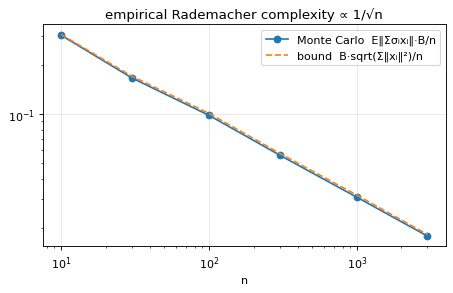

estimate × √n (roughly constant): [0.956 0.909 0.979 0.969 0.978 0.981]


In [6]:
rng, B = np.random.default_rng(0), 1.0
ns, est, bound = [10, 30, 100, 300, 1000, 3000], [], []
for n in ns:
    X = rng.normal(size=(n, 10)) / np.sqrt(10)
    sig = rng.choice([-1, 1], size=(2000, n))
    est.append(B / n * np.linalg.norm(sig @ X, axis=1).mean())
    bound.append(B / n * np.sqrt((X ** 2).sum()))
plt.loglog(ns, est, "o-", label="Monte Carlo  E‖Σσᵢxᵢ‖·B/n"); plt.loglog(ns, bound, "--", label="bound  B·sqrt(Σ‖xᵢ‖²)/n")
plt.xlabel("n"); plt.legend(); plt.title("empirical Rademacher complexity ∝ 1/√n"); plt.show()
print("estimate × √n (roughly constant):", np.round(np.array(est) * np.sqrt(ns), 3))

## 6. VC dimension of half-planes in $\mathbb R^2$ is 3

A labeling is linearly separable iff the LP "find $(w,b)$ with $y_i(w^\top x_i+b)\ge1$" is feasible. Three points in general position: all $2^3$ labelings are separable. Four points: some labeling always fails (Radon's theorem), here tried on 2,000 random 4-point sets.

In [7]:
from itertools import product
from scipy.optimize import linprog
from math import comb
def separable(X, y):
    A = -y[:, None] * np.c_[X, np.ones(len(X))]      # -y(w·x+b) <= -1
    return linprog(np.zeros(3), A_ub=A, b_ub=-np.ones(len(X)), bounds=[(None, None)] * 3).status == 0
def shattered(X):
    return all(separable(X, np.array(lab)) for lab in product([-1, 1], repeat=len(X)))
rng = np.random.default_rng(0)
print("3 random points shattered:", shattered(rng.normal(size=(3, 2))))
print("fraction of 2,000 random 4-point sets shattered:", np.mean([shattered(rng.normal(size=(4, 2))) for _ in range(2000)]))
d = 3
print("\n n   2^n    Sauer–Shelah bound Σ_{i≤d} C(n,i)")
for n in (3, 4, 5, 10, 20):
    print(f"{n:2d}  {2**n:7d}  {sum(comb(n, i) for i in range(d + 1)):6d}")

3 random points shattered: True


fraction of 2,000 random 4-point sets shattered: 0.0

 n   2^n    Sauer–Shelah bound Σ_{i≤d} C(n,i)
 3        8       8
 4       16      15
 5       32      26
10     1024     176
20  1048576    1351


## 7. Gradient descent vs Nesterov acceleration

On a quadratic with condition number $\kappa=L/\mu=100$, gradient descent with step $1/L$ contracts the error by about $(1-1/\kappa)$ per step, while Nesterov's method contracts it by about $(1-1/\sqrt\kappa)$. That's 10× fewer iterations here.

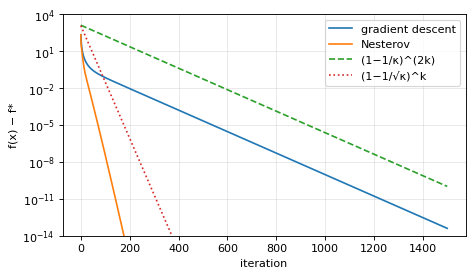

iterations to reach f − f* < 1e-8:  GD 882    Nesterov 108    (√κ = 10)


In [8]:
L_, mu_ = 100.0, 1.0
A = np.diag(np.linspace(mu_, L_, 50)); f = lambda x: 0.5 * x @ A @ x
x0 = np.ones(50); K = 1500
x = x0.copy(); gd = []
for _ in range(K): x = x - (A @ x) / L_; gd.append(f(x))
x, yv = x0.copy(), x0.copy(); q = np.sqrt(mu_ / L_); beta = (1 - q) / (1 + q); agd = []
for _ in range(K):
    x_new = yv - (A @ yv) / L_; yv = x_new + beta * (x_new - x); x = x_new; agd.append(f(x))
k = np.arange(1, K + 1)
plt.semilogy(gd, label="gradient descent"); plt.semilogy(agd, label="Nesterov")
plt.semilogy(f(x0) * (1 - mu_/L_) ** (2*k), "--", label="(1−1/κ)^(2k)")
plt.semilogy(f(x0) * (1 - np.sqrt(mu_/L_)) ** k, ":", label="(1−1/√κ)^k")
plt.ylim(1e-14, 1e4); plt.xlabel("iteration"); plt.ylabel("f(x) − f*"); plt.legend(); plt.show()
first = lambda h: int(np.argmax(np.array(h) < 1e-8)) + 1
print("iterations to reach f − f* < 1e-8:  GD", first(gd), "   Nesterov", first(agd), f"   (√κ = {np.sqrt(L_/mu_):.0f})")

## 8. Proximal gradient for the lasso

For $\min_w\frac1{2n}\lVert y-Xw\rVert^2+\alpha\lVert w\rVert_1$ (scikit-learn's scaling), the proximal step of the $\ell_1$ term is soft thresholding. ISTA converges at $O(1/k)$, FISTA at $O(1/k^2)$, and both land on scikit-learn's coordinate-descent answer.

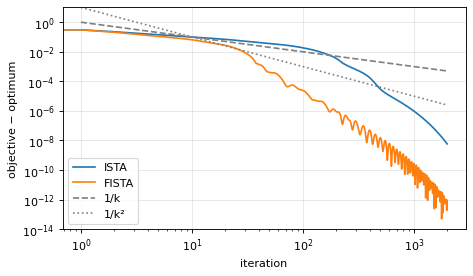

after 100 iterations: ISTA gap 1.9e-02, FISTA gap 2.5e-05
max |FISTA − scikit-learn| = 3.6e-06;  non-zeros: 36 of 200


In [9]:
from sklearn.linear_model import Lasso
rng = np.random.default_rng(0)
n, p, alpha = 50, 200, 0.05                      # p > n and correlated columns: a hard, non-strongly-convex problem
X = rng.normal(size=(n, p)); X[:, 1:] = 0.8 * X[:, :-1] + 0.6 * X[:, 1:]
w_true = np.r_[3, -2, 1.5, np.zeros(p - 3)]; y = X @ w_true + 0.5 * rng.normal(size=n)
obj = lambda w: 0.5 / n * np.sum((y - X @ w) ** 2) + alpha * np.abs(w).sum()
Lg = np.linalg.eigvalsh(X.T @ X / n).max()
soft = lambda v, t: np.sign(v) * np.maximum(np.abs(v) - t, 0)
grad = lambda w: X.T @ (X @ w - y) / n
w = np.zeros(p); ista = []
for _ in range(2000): w = soft(w - grad(w) / Lg, alpha / Lg); ista.append(obj(w))
w_f, z, tk = np.zeros(p), np.zeros(p), 1.0; fista = []
for _ in range(2000):
    w_new = soft(z - grad(z) / Lg, alpha / Lg); t_new = (1 + np.sqrt(1 + 4 * tk**2)) / 2
    z = w_new + (tk - 1) / t_new * (w_new - w_f); w_f, tk = w_new, t_new; fista.append(obj(w_f))
sk = Lasso(alpha=alpha, fit_intercept=False, tol=1e-14, max_iter=1_000_000).fit(X, y).coef_
fstar = min(obj(sk), min(ista), min(fista))
k = np.arange(1, 2001)
plt.loglog(np.array(ista) - fstar + 1e-16, label="ISTA"); plt.loglog(np.array(fista) - fstar + 1e-16, label="FISTA")
plt.loglog(k, 1 / k, "--", color="gray", label="1/k"); plt.loglog(k, 10 / k**2, ":", color="gray", label="1/k²")
plt.ylim(1e-14, 10); plt.xlabel("iteration"); plt.ylabel("objective − optimum"); plt.legend(); plt.show()
print(f"after 100 iterations: ISTA gap {ista[99] - fstar:.1e}, FISTA gap {fista[99] - fstar:.1e}")
print(f"max |FISTA − scikit-learn| = {np.abs(w_f - sk).max():.1e};  non-zeros: {(np.abs(sk) > 1e-8).sum()} of {p}")

## 9. SGD: constant vs decaying step size

On noisy least squares, a constant step converges fast and then bounces around a noise floor proportional to the step size. A decaying step $\eta_t=\eta_0/(1+t/t_0)$ keeps making progress.

constant 0.02              final ‖w − w_LS‖² = 1.07e-01


constant 0.005             final ‖w − w_LS‖² = 4.73e-02
decaying 0.02/(1+t/2000)   final ‖w − w_LS‖² = 5.84e-03


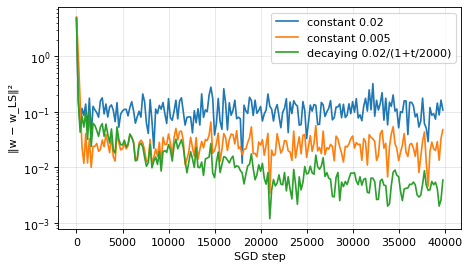

In [10]:
rng = np.random.default_rng(0)
n, p = 5000, 10
X = rng.normal(size=(n, p)); w_star = rng.normal(size=p); y = X @ w_star + rng.normal(size=n)
w_ls = np.linalg.lstsq(X, y, rcond=None)[0]
def sgd(step, T=40_000, seed=1):
    r = np.random.default_rng(seed); w = np.zeros(p); err = []
    for t in range(T):
        i = r.integers(n); w -= step(t) * (X[i] @ w - y[i]) * X[i]
        if t % 200 == 0: err.append(np.sum((w - w_ls) ** 2))
    return err
for name, step in [("constant 0.02", lambda t: 0.02), ("constant 0.005", lambda t: 0.005), ("decaying 0.02/(1+t/2000)", lambda t: 0.02 / (1 + t / 2000))]:
    e = sgd(step); plt.semilogy(np.arange(len(e)) * 200, e, label=name); print(f"{name:26s} final ‖w − w_LS‖² = {e[-1]:.2e}")
plt.xlabel("SGD step"); plt.ylabel("‖w − w_LS‖²"); plt.legend(); plt.show()

## 10. Wide networks train lazily

A two-layer ReLU network $f(x)=\frac1{\sqrt m}\sum_ja_j\,\mathrm{ReLU}(w_j^\top x)$ trained by gradient descent. As the width $m$ grows, it still fits the data, but the first-layer weights move less and less from their initialization, about $\propto1/\sqrt m$. This is the regime where the neural-tangent-kernel analysis applies.

width     10: training MSE 7.8e-04   relative weight change 1.0405
width    100: training MSE 1.9e-05   relative weight change 0.2654


width   1000: training MSE 9.5e-08   relative weight change 0.0682


width  10000: training MSE 2.1e-07   relative weight change 0.0234


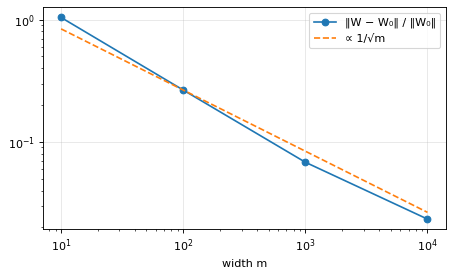

In [11]:
rng = np.random.default_rng(0)
n, d = 20, 5
X = rng.normal(size=(n, d)); X /= np.linalg.norm(X, axis=1, keepdims=True); y = np.sin(3 * X[:, 0])
widths, moves = [10, 100, 1000, 10000], []
for m in widths:
    r = np.random.default_rng(1); W0 = r.normal(size=(m, d)); a = r.choice([-1.0, 1.0], m); W = W0.copy()
    f = lambda W: np.maximum(X @ W.T, 0) @ a / np.sqrt(m)
    for _ in range(2000):
        res = f(W) - y
        W -= 1.0 * ((res[:, None] * (X @ W.T > 0)) * a).T @ X / np.sqrt(m) / n
    moves.append(np.linalg.norm(W - W0) / np.linalg.norm(W0))
    print(f"width {m:6d}: training MSE {np.mean((f(W) - y)**2):.1e}   relative weight change {moves[-1]:.4f}")
plt.loglog(widths, moves, "o-", label="‖W − W₀‖ / ‖W₀‖"); plt.loglog(widths, moves[1] * np.sqrt(100 / np.array(widths)), "--", label="∝ 1/√m")
plt.xlabel("width m"); plt.legend(); plt.show()